# ARTI 403 - Image Processing
## Lab 3 - Image Manipulations using OpenCV

**Name:** Mohammed Saeed Alamodi | **ID:** 2240009007

Covers the Lab 3 procedural steps (read/load/save an image, color space conversion) plus the two
assessment tasks (geometric transformations and intensity transformations).

Note: `cv2.imshow()` / `cv2.waitKey()` don't work inside a notebook, so matplotlib is used instead
to display the images.

### Setup
Make an `images` folder and grab a sample color image to use as `input.jpg`.

In [1]:
import os
import numpy as np
from PIL import Image
from skimage import data

os.makedirs('images', exist_ok=True)

if not os.path.exists('images/input.jpg'):
    Image.fromarray(data.astronaut()).save('images/input.jpg')

print('Images ready:', sorted(os.listdir('images')))

Images ready: ['input.jpg']


## Procedural Steps
### Step #1: Read an image using the OpenCV library

<class 'numpy.ndarray'>
Shape (H, W, C): (512, 512, 3)


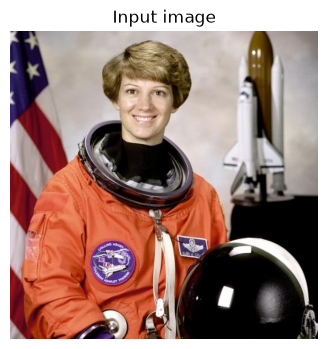

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images/input.jpg')
print(type(img))
print('Shape (H, W, C):', img.shape)

plt.figure(figsize=(4, 4))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Input image')
plt.axis('off')
plt.show()

### Step #2: Load an image in grayscale mode
Load the image directly in grayscale mode.

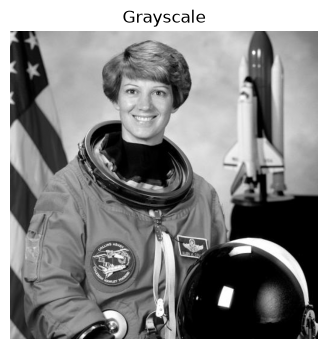

In [3]:
gray_img = cv2.imread('images/input.jpg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(4, 4))
plt.imshow(gray_img, cmap='gray')
plt.title('Grayscale')
plt.axis('off')
plt.show()

### Step #3: Save an image

In [4]:
cv2.imwrite('images/output.jpg', gray_img)
print('Saved images/output.jpg')

Saved images/output.jpg


### Step #4: Convert an image to different color spaces
Convert to grayscale with `cv2.cvtColor`, check the available `COLOR_*` flags, then convert to
YUV and look at the Y, U and V channels separately.

374 color conversion flags available, e.g.: ['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR']


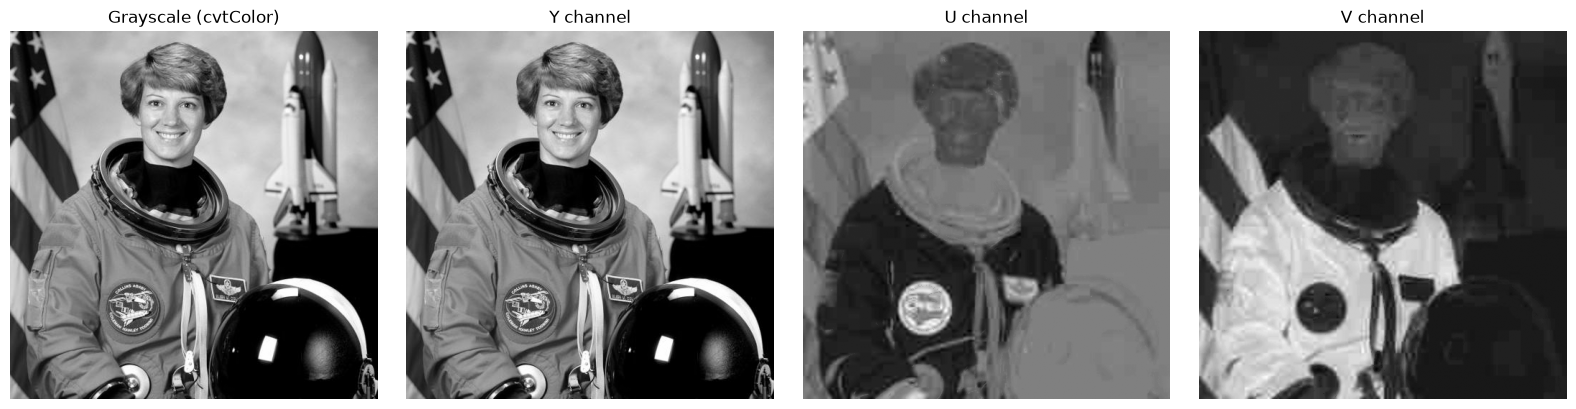

In [5]:
gray_from_color = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

color_flags = [x for x in dir(cv2) if x.startswith('COLOR_')]
print(f'{len(color_flags)} color conversion flags available, e.g.:', color_flags[:10])

yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(gray_from_color, cmap='gray'); axes[0].set_title('Grayscale (cvtColor)')
axes[1].imshow(yuv_img[:, :, 0], cmap='gray'); axes[1].set_title('Y channel')
axes[2].imshow(yuv_img[:, :, 1], cmap='gray'); axes[2].set_title('U channel')
axes[3].imshow(yuv_img[:, :, 2], cmap='gray'); axes[3].set_title('V channel')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Practical Session Tasks (Assessment)

### Task #1: Geometric Transformations
Apply the following geometric transformations to the image using OpenCV:
1. Increase the size of the image.
2. Rotate the image by 120 degrees.
3. Perform a shear operation on the image.

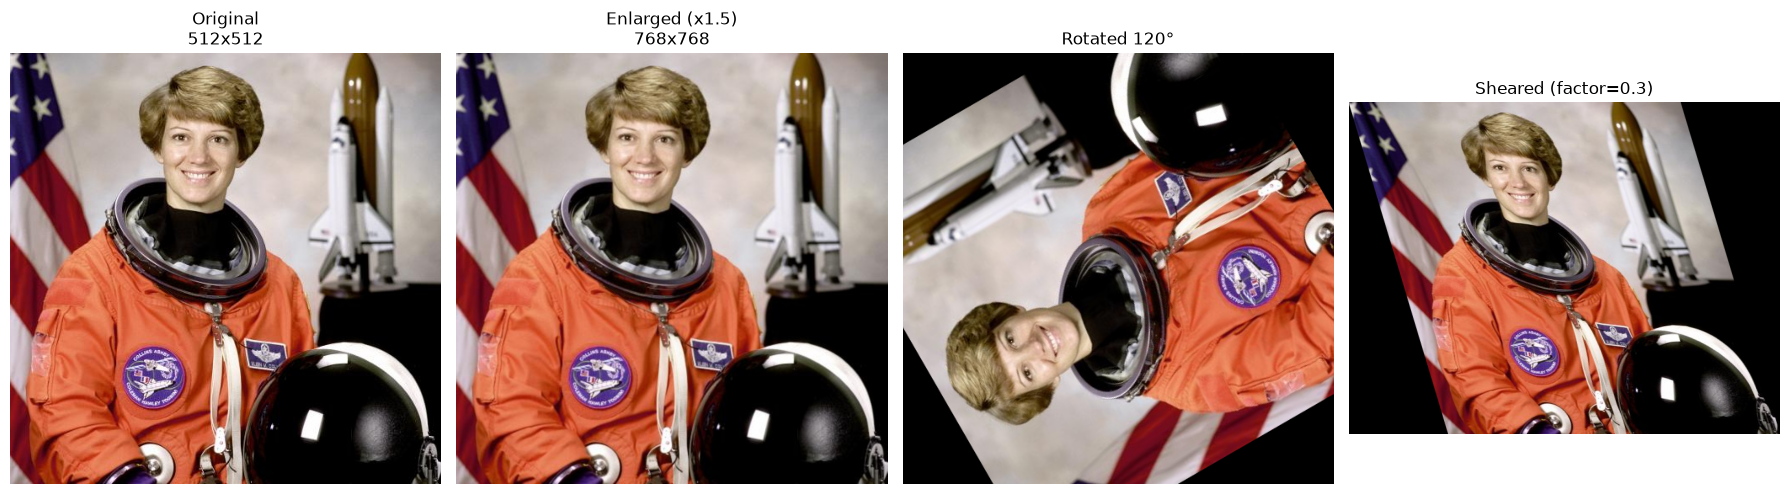

In [6]:
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = rgb_img.shape[:2]

# 1. Increase the size of the image (scale up by 1.5x)
scale = 1.5
enlarged = cv2.resize(rgb_img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_LINEAR)

# 2. Rotate the image by 120 degrees around its center
center = (w // 2, h // 2)
rot_matrix = cv2.getRotationMatrix2D(center, 120, 1.0)
rotated = cv2.warpAffine(rgb_img, rot_matrix, (w, h))

# 3. Shear the image along the x-axis; widen the canvas so content isn't clipped
shear_factor = 0.3
shear_matrix = np.float32([[1, shear_factor, 0], [0, 1, 0]])
new_w = int(w + shear_factor * h)
sheared = cv2.warpAffine(rgb_img, shear_matrix, (new_w, h))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(rgb_img); axes[0].set_title(f'Original\n{w}x{h}')
axes[1].imshow(enlarged); axes[1].set_title(f'Enlarged (x{scale})\n{enlarged.shape[1]}x{enlarged.shape[0]}')
axes[2].imshow(rotated); axes[2].set_title('Rotated 120°')
axes[3].imshow(sheared); axes[3].set_title(f'Sheared (factor={shear_factor})')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

### Task #2: Intensity Transformations
Apply the following intensity transformations to the image:
1. Negative image.
2. Log transformation (choosing an appropriate constant `c`).
3. Power-law (gamma) transformation, choosing a gamma that increases contrast.

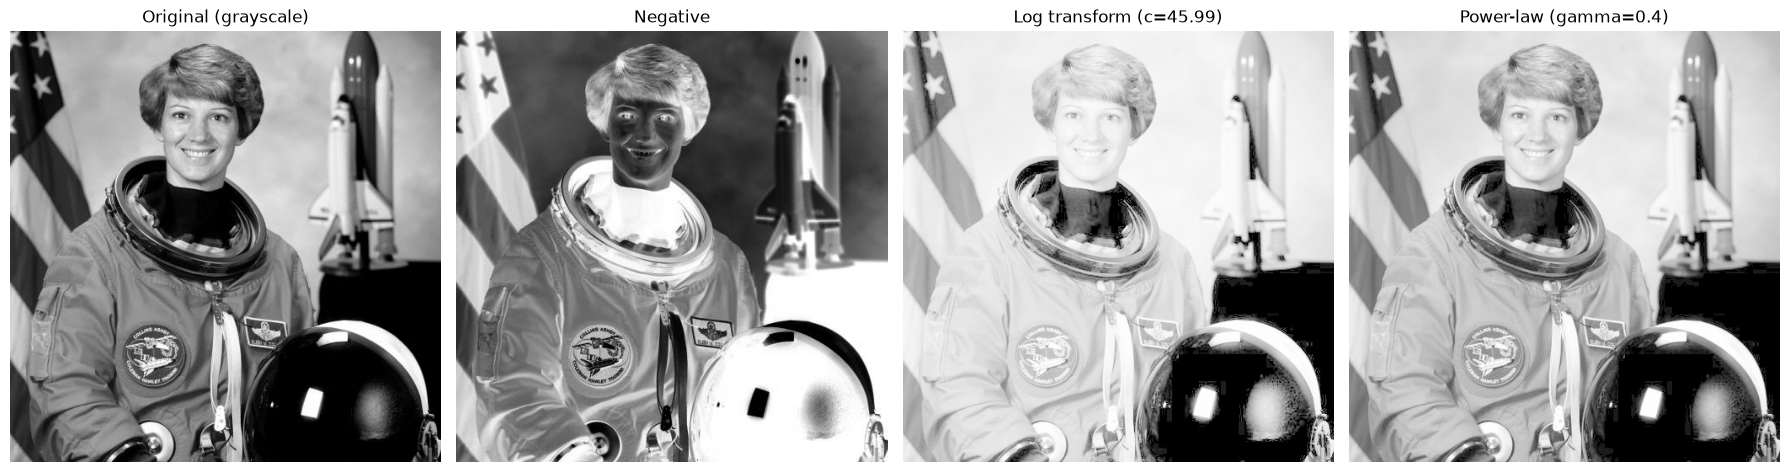

In [7]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float64)

# 1. Negative image: s = 255 - r
negative = 255 - gray

# 2. Log transform: s = c * log(1 + r); c is chosen so the brightest input pixel maps to 255
c_log = 255 / np.log(1 + np.max(gray))
log_img = c_log * np.log(1 + gray)

# 3. Power-law (gamma) transform: s = c * r^gamma
# gamma < 1 boosts dark/mid intensities, increasing contrast in the shadow regions
gamma = 0.4
c_gamma = 255 / (255.0 ** gamma)
gamma_img = c_gamma * (gray ** gamma)

negative = negative.astype(np.uint8)
log_img = np.clip(log_img, 0, 255).astype(np.uint8)
gamma_img = np.clip(gamma_img, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(gray.astype(np.uint8), cmap='gray'); axes[0].set_title('Original (grayscale)')
axes[1].imshow(negative, cmap='gray'); axes[1].set_title('Negative')
axes[2].imshow(log_img, cmap='gray'); axes[2].set_title(f'Log transform (c={c_log:.2f})')
axes[3].imshow(gamma_img, cmap='gray'); axes[3].set_title(f'Power-law (gamma={gamma})')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Observations**
- Enlarging the image with `cv2.resize` just interpolates new pixels between the existing ones -
  the content is the same, it just looks a bit softer.
- Rotating by 120 degrees around the center leaves black corners in the output, since the rotated
  content no longer covers the whole rectangular frame.
- The shear pushes each row sideways based on its y-coordinate. I widened the canvas so the
  sheared image doesn't get cut off.
- The negative image just flips the intensities (bright becomes dark and vice versa).
- The log transform stretches the dark values and compresses the bright ones, so the darker parts
  of the image (like the shadowed suit) get brighter without blowing out the background.
- Using gamma = 0.4 (less than 1) for the power-law transform boosts the darker pixels more than
  the bright ones, which increases contrast/detail in the shadows.